In [ ]:
# Before applying on unseen material, doing an independent test set will help evlauatye the generalizability of the model,
# and what to expect, e.g. common problems such as duplicated bounding boxes. 
# For more indepth explanations behind the methods applied, see chapter 3. 

In [47]:
# Chunk 0 - imports and setup of directories
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO



def find_repo_root(start=None, marker=".git"):
    path = Path(start or Path.cwd()).resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find a repo root (looking for '{marker}')")


REPO_ROOT = find_repo_root()

CONFIG = {
    # this is the annotated test set
    "HUMAN_ANNOTATIONS": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "annotations"/"instances_default.json",
    "TEST_IMAGES_DIR": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "images"/ "default",
    # change the model path if you are using another model
    "MODEL_PATH": REPO_ROOT / "use-a-crab-detector" / "model" / "pretrained-crab-detector" / "best.pt",
    "MODEL_PREDICTIONS": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "predictions.json",
    "OUTPUT_DIR": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "results",
    "THRESHOLDS": [0.0, 0.5, 0.75], # you can freely change, add or remove these as youd like
    "SAVE_ANNOTATED_IMAGES": False,  # set True to also save images with predicted boxes drawn in, for spot-checking

}
CONFIG["OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)

In [55]:
# Chunk 1 - station helpers
# Matches the BRUV station ID out of a filename, e.g. "..._KV5_RA3_..." -> "KV5".
# Same convention used throughout the repo (see Chapter 1).

STATION_PATTERN = re.compile(r"_([A-Z]{2,3}\d{1,2})_[A-Z]{1,4}\d{1,2}_[^/\\]*$", re.IGNORECASE)
FRAME_PATTERN = re.compile(r"(?:frame_)?(\d+)(?:_\d+)?\.jpg$", re.IGNORECASE)


def station_from_filename(fname: str) -> str | None:
    m = STATION_PATTERN.search(fname)
    return m.group(1) if m else None


def frame_no(fname: str) -> int:
    m = FRAME_PATTERN.search(fname)
    return int(m.group(1)) if m else 10**9


def is_crab(ann: dict, categories: dict) -> bool:
    """Human annotator annotations: Decapods + Species == Crab."""
    if categories.get(ann.get("category_id"), "").lower() != "decapods":
        return False
    attrs = ann.get("attributes") or {}
    species = str(attrs.get("Species") or attrs.get("species") or "").strip().lower()
    return species == "crab"


def calculate_iou(box1, box2) -> float:
    if not box1 or not box2:
        return 0.0
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0.0

In [49]:
# Chunk 2 - run the detector on the test-set images to generate predictions.json

def run_detector_on_test_images(images_dir: Path, model_path: Path, output_path: Path, save_annotated: bool = False) -> list:
    """
    Run the trained model on every image in images_dir and save the
    detections to output_path in the format the rest of this notebook
    expects. Runs on a folder of still images, not a video, so each
    prediction lines up exactly with the image a human already annotated
    (matched by filename).
    """
    model = YOLO(str(model_path))
    results = model.predict(
        source=str(images_dir),
        conf=0.1,
        imgsz=960,
        stream=True,
        verbose=False,
        save=save_annotated,
        project=str(output_path.parent / "annotated_images") if save_annotated else None,
        name="run",
        exist_ok=True,
    )

    predictions = []
    for result in results:
        image_id = Path(result.path).stem
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            predictions.append({
                "image_id": image_id,
                "score": float(box.conf[0]),
                "bbox": [x1, y1, x2 - x1, y2 - y1],
            })

    output_path.write_text(json.dumps(predictions, indent=2))
    print(f"Saved {len(predictions)} detections to {output_path}")
    return predictions


run_detector_on_test_images(
    CONFIG["TEST_IMAGES_DIR"], CONFIG["MODEL_PATH"], CONFIG["MODEL_PREDICTIONS"],
    save_annotated=CONFIG["SAVE_ANNOTATED_IMAGES"],
)

Saved 66 detections to /scratch/disk4/crab_model_gina/crabs-on-camera/use-a-crab-detector/data/test_predictions/predictions.json


[{'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0005',
  'score': 0.6854787468910217,
  'bbox': [1115.329345703125,
   698.0477294921875,
   187.04345703125,
   209.7398681640625]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0006',
  'score': 0.8621957898139954,
  'bbox': [1105.2176513671875,
   714.7822265625,
   185.66162109375,
   204.8760986328125]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0007',
  'score': 0.887154757976532,
  'bbox': [1106.34765625, 722.7586669921875, 176.306640625, 216.296630859375]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0008',
  'score': 0.8748438954353333,
  'bbox': [1114.8375244140625,
   729.5535888671875,
   171.262451171875,
   217.060546875]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0009',
  'score': 0.8506923913955688,
  'bbox': [1096.518798828125, 699.366943359375, 132.69921875, 218.396484375]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_N

In [50]:
# Chunk 3 - per-station stats for the human-annotated ground truth

def process_human_annotations(coco_path: Path, dataset_name: str = "human_annotator") -> tuple:
    """Per-station maxN and meanN from the human-annotated test set."""
    data = json.loads(coco_path.read_text(encoding="utf-8"))
    images = {img["id"]: img for img in data["images"]}
    categories = {c["id"]: c.get("name", "") for c in data["categories"]}

    crabs_per_image = Counter()
    total_crabs = 0
    for ann in data["annotations"]:
        if is_crab(ann, categories):
            iid = ann.get("image_id")
            if iid is not None:
                crabs_per_image[iid] += 1
                total_crabs += 1

    station_data = defaultdict(list)
    for img_id, img in images.items():
        fname = img.get("file_name", "")
        station = station_from_filename(fname)
        if not station:
            continue
        station_data[station].append({
            "image_id": img_id,
            "frame": frame_no(fname),
            "crab_count": crabs_per_image.get(img_id, 0),
        })

    rows = []
    for station, images_list in station_data.items():
        crab_counts = [img["crab_count"] for img in images_list]
        # Tie goes to earliest frame, matching the original thesis analysis
        best_image = sorted(images_list, key=lambda x: (-x["crab_count"], x["frame"]))[0]
        rows.append({
            "station": station,
            "maxN": best_image["crab_count"],
            "meanN": np.mean(crab_counts),
            "medianN": np.median(crab_counts),
            "stdN": np.std(crab_counts),
            "total_images": len(images_list),
            "total_crabs": sum(crab_counts),
            "dataset": dataset_name,
        })

    result = pd.DataFrame(rows).sort_values("station").reset_index(drop=True)
    return result, total_crabs

In [51]:
# Chunk 4 - per-station stats for the model's predictions, at a given confidence threshold

def process_predictions_with_threshold(
    coco_path: Path,
    pred_path: Path,
    confidence_threshold: float = 0.0,
    apply_nms: bool = True,
    dataset_name: str = "model_predictions",
) -> tuple:
    """Per-station maxN and meanN from the model's predictions at one threshold."""
    coco = json.loads(coco_path.read_text())
    preds = json.loads(pred_path.read_text())

    stem_to_info = {}
    all_stations = set()
    for img in coco["images"]:
        fname = img["file_name"]
        stem = Path(fname).stem
        station = station_from_filename(fname)
        if station:
            stem_to_info[stem] = {"station": station, "coco_id": img["id"], "fname": fname, "frame": frame_no(fname)}
            all_stations.add(station)

    filtered_preds = [p for p in preds if p.get("score", 0) >= confidence_threshold]
    total_predicted_crabs = len(filtered_preds)

    preds_by_stem = defaultdict(list)
    for pred in filtered_preds:
        stem = str(pred.get("image_id", ""))
        if stem in stem_to_info:
            preds_by_stem[stem].append(pred)

    if apply_nms:
        for stem, stem_preds in preds_by_stem.items():
            if len(stem_preds) > 1:
                stem_preds.sort(key=lambda p: p.get("score", 0), reverse=True)
                kept = []
                for pred in stem_preds:
                    if not any(calculate_iou(pred.get("bbox"), k.get("bbox")) > 0.5 for k in kept):
                        kept.append(pred)
                preds_by_stem[stem] = kept

    crabs_per_stem = {stem: len(p) for stem, p in preds_by_stem.items()}

    station_data = defaultdict(list)
    for stem, crab_count in crabs_per_stem.items():
        info = stem_to_info[stem]
        station_data[info["station"]].append({"image_id": info["coco_id"], "frame": info["frame"], "crab_count": crab_count})

    rows = []
    for station in sorted(all_stations):
        station_images = [info for info in stem_to_info.values() if info["station"] == station]
        # Zero-fill: every image at this station counts, even ones with no predictions above threshold
        crab_counts_dict = {img["coco_id"]: 0 for img in station_images}
        for img_data in station_data.get(station, []):
            crab_counts_dict[img_data["image_id"]] = img_data["crab_count"]
        crab_counts = list(crab_counts_dict.values())

        images_list = station_data.get(station, [])
        best_image = sorted(images_list, key=lambda x: (-x["crab_count"], x["frame"]))[0] if images_list else {"crab_count": 0}

        rows.append({
            "station": station,
            "maxN": best_image["crab_count"],
            "meanN": np.mean(crab_counts),
            "medianN": np.median(crab_counts),
            "stdN": np.std(crab_counts),
            "total_images": len(station_images),
            "total_crabs": sum(crab_counts),
            "dataset": dataset_name,
        })

    result = pd.DataFrame(rows).sort_values("station").reset_index(drop=True)
    return result, total_predicted_crabs

In [52]:
# Chunk 5 - barplots to visually compare the predictions and the human ground truth

def plot_station_comparison(comparison_df: pd.DataFrame, metric: str, thresholds: list, output_path: Path) -> None:
    """
    Grouped bar chart, one group per station: the human ground truth next
    to the model's value at each threshold, for one metric at a time
    (e.g. "total_crabs", "maxN", or "meanN").
    """
    stations = sorted(comparison_df["station"].unique())
    x = np.arange(len(stations))
    width = 0.8 / (len(thresholds) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    human_values = comparison_df.drop_duplicates("station").set_index("station")[f"{metric}_human"].reindex(stations)
    ax.bar(x - 0.4 + width / 2, human_values, width, label="Human", color="green", alpha=0.8)

    for i, threshold in enumerate(thresholds, start=1):
        model_values = comparison_df[comparison_df["threshold"] == threshold].set_index("station")[f"{metric}_model"].reindex(stations)
        ax.bar(x - 0.4 + width / 2 + i * width, model_values, width, label=f"Model (threshold={threshold})", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(stations, rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by station and threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    threshold station  total_crabs_human  total_crabs_model  maxN_human  \
0        0.00     BR2                  9                 19           1   
1        0.00     NG4                 15                 16           1   
2        0.00     UR1                 25                 19           2   
3        0.00     VA3                 28                 10           2   
4        0.00     VE4                  0                  0           0   
5        0.50     BR2                  9                  2           1   
6        0.50     NG4                 15                 14           1   
7        0.50     UR1                 25                 17           2   
8        0.50     VA3                 28                  2           2   
9        0.50     VE4                  0                  0           0   
10       0.75     BR2                  9                  0           1   
11       0.75     NG4                 15                 11           1   
12       0.75     UR1    

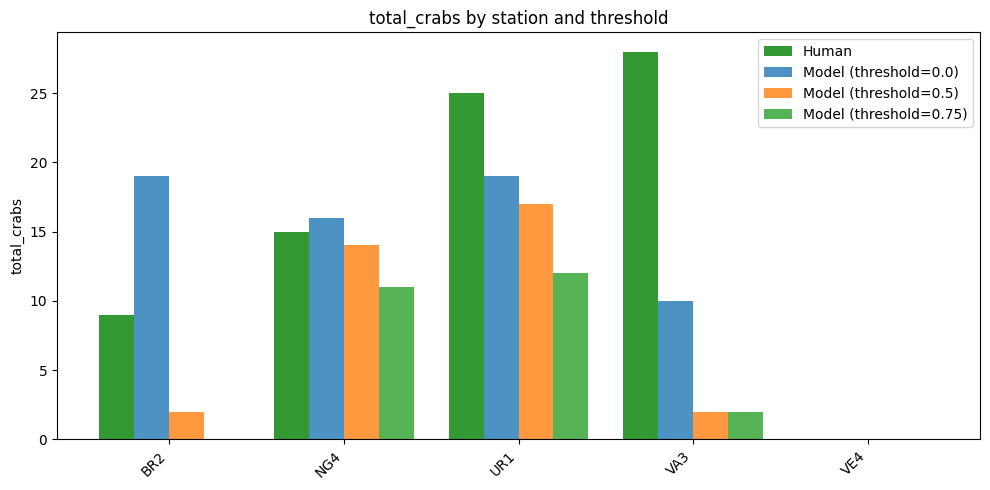

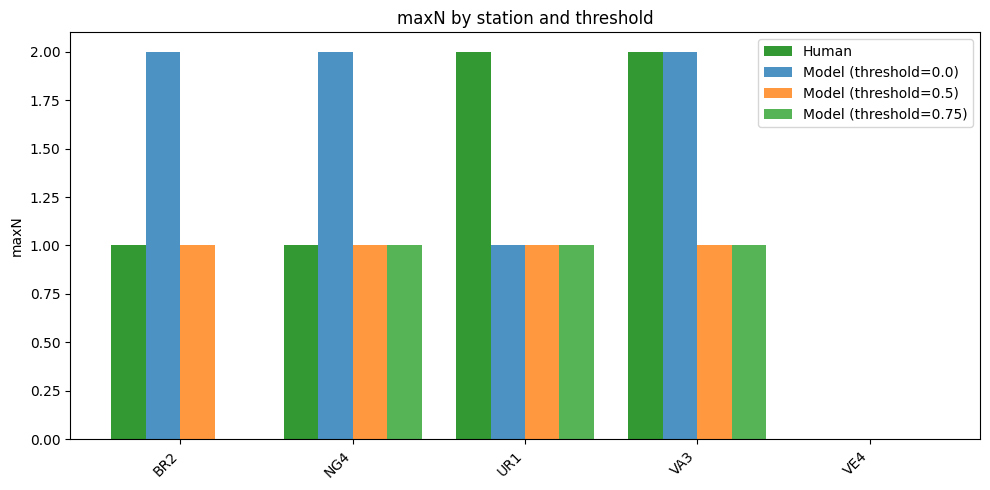

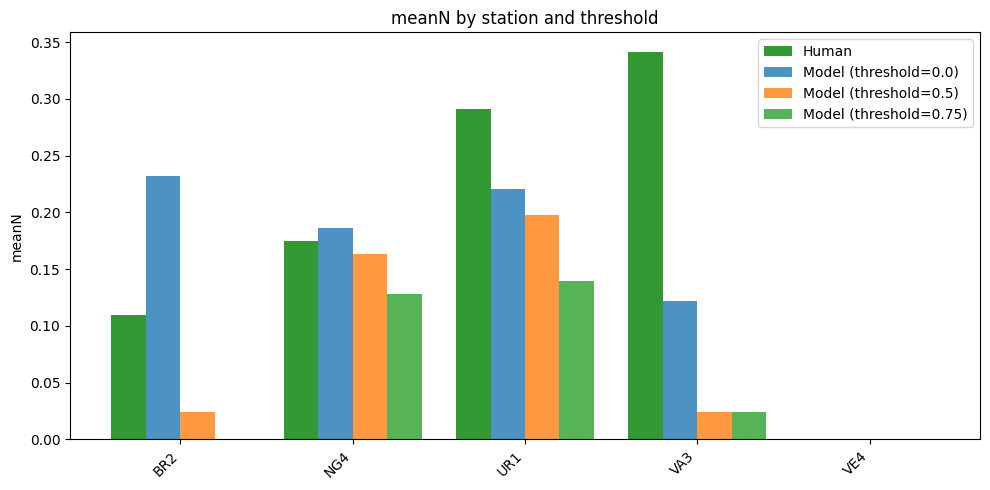

In [56]:
# Chunk 6 - run it and save CSV to use in R

df_human, total_human_crabs = process_human_annotations(CONFIG["HUMAN_ANNOTATIONS"])

comparison_rows = []
for threshold in CONFIG["THRESHOLDS"]:
    df_pred, _ = process_predictions_with_threshold(CONFIG["HUMAN_ANNOTATIONS"], CONFIG["MODEL_PREDICTIONS"], threshold)
    comparison = df_human.merge(df_pred, on="station", suffixes=("_human", "_model"))
    comparison["threshold"] = threshold
    comparison_rows.append(comparison[["threshold", "station", "total_crabs_human", "total_crabs_model", "maxN_human", "maxN_model", "meanN_human", "meanN_model"]])

comparison_df = pd.concat(comparison_rows, ignore_index=True)
comparison_df.to_csv(CONFIG["OUTPUT_DIR"] / "threshold_summary.csv", index=False)
print(comparison_df)

for metric in ["total_crabs", "maxN", "meanN"]:
    plot_station_comparison(comparison_df, metric, CONFIG["THRESHOLDS"], CONFIG["OUTPUT_DIR"] / f"{metric}_by_station.png")